In [1]:
import pandas as pd
import json, os
from collections import Counter

# ====== 文件路径 ======
mos_path = "/home/you/workspace/son/FastSpeech2/preprocessed_data/MSP/utmos_scores.csv"
label_json_path = "/home/you/workspace/database/MSP/Labels/Train.json"
output_json = "filtered_data.json"
# =====================

# 1. 筛选 MOS > 2.9 的数据
min_score = 2.9
mos_df = pd.read_csv(mos_path)
mos_df["file_name"] = mos_df["wav_path"].apply(lambda x: os.path.basename(x))
qualified_utt_ids = set(mos_df[mos_df["utmos_score"] > min_score]["file_name"])
mos_score_dict = dict(zip(mos_df["file_name"], mos_df["utmos_score"]))

# 2. 读取标签 JSON 文件
with open(label_json_path, "r", encoding="utf-8") as f:
    label_data = json.load(f)

# 3. 第一次筛选：mos高 + 非unknown + 非X情绪
filtered_data = {
    utt: meta
    for utt, meta in label_data.items()
    if utt in qualified_utt_ids
    and meta.get("SpkrID", "").lower() != "unknown"
    and meta.get("EmoClass", "").upper() != "X"
}

# 4. 统计说话人数据量，排除样本数 < 20 的说话人
spkr_counter = Counter([meta["SpkrID"] for meta in filtered_data.values()])
valid_speakers = {spkr for spkr, count in spkr_counter.items() if count >= 20}

# 5. 第二次筛选：保留说话人样本数 ≥ 20
final_data = {
    utt: meta
    for utt, meta in filtered_data.items()
    if meta["SpkrID"] in valid_speakers
}

# ⭐ 6. 写入 MOS 分数
for utt, meta in final_data.items():
    if utt in mos_score_dict:
        meta["MOS"] = mos_score_dict[utt]

# 7. 保存结果
with open(output_json, "w", encoding="utf-8") as f:
    json.dump(final_data, f, indent=4, ensure_ascii=False)

print(f"✅ 最终保留 {len(final_data)} 条数据，保存为：{output_json}")


✅ 最终保留 15116 条数据，保存为：filtered_data.json


🎭 情绪分布统计：
N: 7865 条
S: 1216 条
D: 355 条
O: 445 条
A: 713 条
C: 683 条
F: 252 条
H: 2976 条
U: 611 条


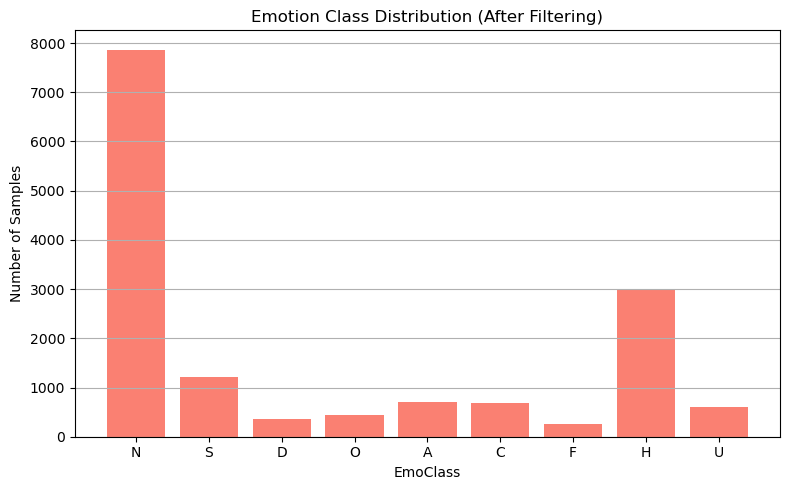

🎭 情绪分布统计：
N: 2845 条
S: 1216 条
D: 355 条
O: 445 条
A: 713 条
C: 683 条
F: 252 条
H: 1500 条
U: 611 条


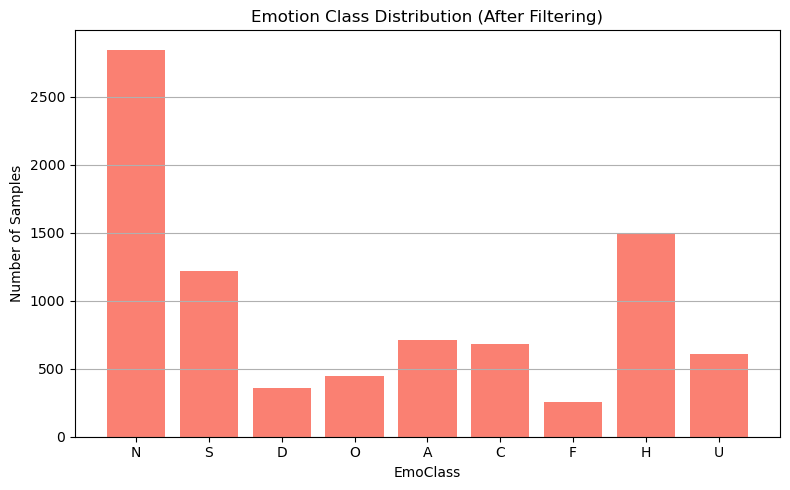

In [6]:
from collections import Counter
import json
import matplotlib.pyplot as plt

def plot_emo_distribution(filtered_json_path):
    # 读取筛选后的数据
    with open(filtered_json_path, "r", encoding="utf-8") as f:
        final_data = json.load(f)

    # 统计情绪类别
    emo_counter = Counter(meta["EmoClass"] for meta in final_data.values())

    # 打印统计结果
    print("🎭 情绪分布统计：")
    for emo, count in emo_counter.items():
        print(f"{emo}: {count} 条")

    # 可视化分布
    plt.figure(figsize=(8, 5))
    plt.bar(emo_counter.keys(), emo_counter.values(), color='salmon')
    plt.xlabel("EmoClass")
    plt.ylabel("Number of Samples")
    plt.title("Emotion Class Distribution (After Filtering)")
    plt.tight_layout()
    plt.grid(axis='y')
    plt.show()

filtered_json_path = "filtered_data.json"
plot_emo_distribution(filtered_json_path)
filtered_json_path = "balanced_filtered_data.json"
plot_emo_distribution(filtered_json_path)


In [5]:
import json
import random
from collections import defaultdict

# 设定目标：每类保留多少条样本（目标均衡后每类样本数）
TARGET_PER_CLASS = 1500  # 可根据实际情况调整

# 读取数据
with open("filtered_data.json", "r") as f:
    data = json.load(f)

# 将数据按情绪分类 & 统计说话人信息
emotion_buckets = defaultdict(list)
speaker_count = defaultdict(int)
for wav, info in data.items():
    emo = info["EmoClass"]
    spk = info["SpkrID"]
    emotion_buckets[emo].append((wav, info))
    speaker_count[spk] += 1

# 开始下采样：优先保留小样本说话人的数据
final_data = dict()
for emo, entries in emotion_buckets.items():
    if len(entries) <= TARGET_PER_CLASS:
        for wav, info in entries:
            final_data[wav] = info
        continue
    
    # 划分说话人
    small_speaker_data = []
    large_speaker_data = []

    for wav, info in entries:
        spk = info["SpkrID"]
        if speaker_count[spk] < 50:  # 小样本说话人阈值
            small_speaker_data.append((wav, info))
        else:
            large_speaker_data.append((wav, info))

    # 优先保留小样本说话人的所有数据
    selected = small_speaker_data
    remaining_needed = TARGET_PER_CLASS - len(selected)

    if remaining_needed > 0:
        # 按 MOS 分数排序降序，保留高质量
        sorted_large = sorted(large_speaker_data, key=lambda x: x[1].get("MOS", 0), reverse=True)
        selected += sorted_large[:remaining_needed]

    for wav, info in selected:
        final_data[wav] = info

print(f"最终样本数: {len(final_data)}")

# 保存结果
with open("balanced_filtered_data.json", "w") as f:
    json.dump(final_data, f, indent=2)


最终样本数: 8620


In [10]:
import os
import shutil
import json
from pathlib import Path
from text import _clean_text

# 路径设定
input_json = "balanced_filtered_data.json"
audio_root = "/home/you/workspace/database/MSP/Audios"
text_root = "/home/you/workspace/database/MSP/Transcripts"
output_root = "/home/you/workspace/son/FastSpeech2/raw_data/MSP_final"

# 创建目标路径
os.makedirs(output_root, exist_ok=True)

# 加载筛选后数据
with open(input_json, "r", encoding="utf-8") as f:
    data = json.load(f)

missing_files = []

for wav_name, info in data.items():
    spkr_id = info["SpkrID"]
    utt_id = wav_name.replace(".wav", "")
    
    # 路径准备
    spkr_out_dir = os.path.join(output_root, spkr_id)
    os.makedirs(spkr_out_dir, exist_ok=True)

    # 复制音频
    src_audio = os.path.join(audio_root, wav_name)
    dst_audio = os.path.join(spkr_out_dir, wav_name)
    if os.path.exists(src_audio):
        shutil.copy(src_audio, dst_audio)
    else:
        missing_files.append(src_audio)
        continue

    # 处理文本
    txt_name = wav_name.replace(".wav", ".txt")
    src_txt = os.path.join(text_root, txt_name)
    dst_lab = os.path.join(spkr_out_dir, wav_name.replace(".wav", ".lab"))
    if os.path.exists(src_txt):
        with open(src_txt, "r", encoding="utf-8") as f:
            raw_text = f.read().strip()
        raw_text = raw_text.replace("-", " ").replace("(", "").replace(")", "")
        cleaned = _clean_text(raw_text, ["english_cleaners"])
        with open(dst_lab, "w", encoding="utf-8") as f:
            f.write(cleaned)
    else:
        missing_files.append(src_txt)

print(f"✅ 拷贝完成：{len(data)} 条。")
if missing_files:
    print(f"⚠️ 缺失文件 {len(missing_files)} 个：")
    for f in missing_files:
        print(" -", f)


✅ 拷贝完成：8620 条。
